<H1>Building a Data Analyst Agent - Complete Tutorial</H1>

<h2>Course Objectives</h2>
<p>- What is a Data Analysis Agent
<p>- Understand concepts , terminology
<p>- Understand Architecture and Solution
<p>- Build a data analysis agent in Python
<p>- Understand pros and cons of the solution

<h2>What is a Data Analyst Agent</h2>

<p> A data analysis agent converts natural language question into data insights</p>

In [20]:
from IPython.display import Video

In [23]:
Video("./videos/demo_dataanalysis_agent.mp4",height=400)

![title](images/IMG_0078.PNG)

<h2>Concepts and Terminologies</h2>

![title](images/IMG_0072.PNG)

# Data Analyst Agent — Full Mode

## What is Full Mode?

**Full Mode** uses OpenAI's **Assistants API with Code Interpreter**.

- Your **actual data file is uploaded to OpenAI's servers**.
- OpenAI's Code Interpreter runs Python code in a sandboxed cloud environment.
- The model can read the real data values, perform analysis, and generate charts — all in the cloud.
- Results (text, code, images) are downloaded back and shown to the user.

### When to use Full Mode
- When you are comfortable sharing data with OpenAI.
- When you need the most capable, autonomous analysis (the model sees real values and can iterate).
- When you want charts and code automatically generated without managing a local Python environment.

### Architecture diagram

```
User message + CSV file
        │
        ▼
  FastAPI Backend
        │  uploads file & sends message
        ▼
  OpenAI Assistants API
     (Code Interpreter)
        │  executes Python in OpenAI sandbox
        ▼
  Run Steps: code + output + images
        │
        ▼
  Backend retrieves results → returns to frontend
```

## Setup

Install the required packages and set your OpenAI API key.

In [ ]:
# Install required packages (uncomment if needed)
# %pip install openai pandas

In [1]:
import os,getpass
import time
import base64
from pathlib import Path
import pandas as pd
import openai

# Set your OpenAI API key
#OPENAI_API_KEY = os.environ.get("OPENAI_API_KEY", "sk-...your-key-here...")
OPENAI_API_KEY = getpass.getpass("Paste your OpenAI API key: ")
client = openai.OpenAI(api_key=OPENAI_API_KEY)

print("OpenAI client ready.")

Paste your OpenAI API key:  ········


OpenAI client ready.


---
## Step 1 — Create an Assistant with Code Interpreter

The **Assistant** is a persistent AI entity that lives in OpenAI. We configure it once with:
- A system prompt (instructions on how to behave)
- The `code_interpreter` tool enabled

In `main.py` this happens inside `init_openai()` (lines 181–225). The assistant is reused across sessions.

In [10]:
ASSISTANT_INSTRUCTIONS = """
You are Jarvis, an expert data analyst assistant. You help users analyze their data by:
1. Understanding the data: explore structure, columns, data types, and statistics.
2. Planning your analysis briefly in 1-2 sentences.
3. Writing clean Python code using pandas, numpy, matplotlib, and seaborn.
4. Creating visualizations with a dark  theme.
5. Explaining insights in plain English with specific numbers.
6. Suggesting 2-3 follow-up questions.
"""

# Check if our assistant already exists, otherwise create it
assistants = client.beta.assistants.list(limit=100)
existing = next((a for a in assistants.data if a.name == "DataJarvis Analyst - Notebook"), None)

if existing:
    assistant = client.beta.assistants.update(
        existing.id,
        instructions=ASSISTANT_INSTRUCTIONS,
        tools=[{"type": "code_interpreter"}],
        model="gpt-4o"
    )
    print(f"Updated existing assistant: {assistant.id}")
else:
    assistant = client.beta.assistants.create(
        name="DataJarvis Analyst - Notebook",
        instructions=ASSISTANT_INSTRUCTIONS,
        tools=[{"type": "code_interpreter"}],
        model="gpt-4o"
    )
    print(f"Created new assistant: {assistant.id}")

/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/3348887040.py:12: DeprecationWarning: deprecated
  assistants = client.beta.assistants.list(limit=100)
/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/3348887040.py:16: DeprecationWarning: deprecated
  assistant = client.beta.assistants.update(


Updated existing assistant: asst_uQizy95OG8gVAKqYNKZqxPBa


---
## Step 2 — Upload the Data File to OpenAI

In Full Mode, the CSV is uploaded to OpenAI's file storage with `purpose="assistants"`.
The file then becomes available inside the Code Interpreter sandbox.

In `main.py` this happens in the `/api/upload` endpoint (lines 911–983).

> **Privacy note:** The raw data values leave your machine and are processed on OpenAI servers.

In [11]:
# Path to the sample cars dataset (relative to this notebook)
DATA_PATH = Path("./data/cars_data.csv")

# Quick preview before uploading
df_preview = pd.read_csv(DATA_PATH)
print(f"Dataset: {len(df_preview)} rows x {len(df_preview.columns)} columns")
df_preview.head(3)

Dataset: 205 rows x 22 columns


,id,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,0,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,2548,dohc,4,130,mpfi,111.0,5000.0,21,27,13495.0
1,1,alfa-romero,gas,std,2,convertible,rwd,front,88.6,168.8,...,2548,dohc,4,130,mpfi,111.0,5000.0,21,27,16500.0
2,2,alfa-romero,gas,std,2,hatchback,rwd,front,94.5,171.2,...,2823,ohcv,6,152,mpfi,154.0,5000.0,19,26,16500.0


In [12]:
# Upload the file to OpenAI — this is what Full Mode does on every session
with open(DATA_PATH, "rb") as f:
    openai_file = client.files.create(
        file=(DATA_PATH.name, f),
        purpose="assistants"
    )

print(f"File uploaded to OpenAI.")
print(f"  File ID : {openai_file.id}")
print(f"  Filename: {openai_file.filename}")
print(f"  Purpose : {openai_file.purpose}")

File uploaded to OpenAI.
  File ID : file-4Hd2LxDUejeDB4uBiMRbQZ
  Filename: cars_data.csv
  Purpose : assistants


---
## Step 3 — Create a Conversation Thread

A **Thread** represents a single conversation with the assistant. Each user session gets its own thread, so history is isolated.

In `main.py` threads are created in `get_session()` (lines 264–295).

In [13]:
thread = client.beta.threads.create()
print(f"Thread created: {thread.id}")

/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/2679685081.py:1: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  thread = client.beta.threads.create()


Thread created: thread_uDPDKIa0o3Gh0Z04bOIwWrPN


---
## Step 4 — Send a Message (with file attachment)

We add the user's question to the thread. The uploaded file is attached so the Code Interpreter can access it.

This corresponds to lines 1136–1156 inside `chat_full_mode()` in `main.py`.

In [14]:
user_question = "What are the top 5 car brands by average price? Create a bar chart."

# Attach the file so Code Interpreter can read it
attachments = [
    {"file_id": openai_file.id, "tools": [{"type": "code_interpreter"}]}
]

message = client.beta.threads.messages.create(
    thread_id=thread.id,
    role="user",
    content=user_question,
    attachments=attachments
)

print(f"Message sent: {message.id}")
print(f"Question    : {user_question}")

/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/2751745777.py:8: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  message = client.beta.threads.messages.create(


Message sent: msg_jHP0s4Upx8QjRC9Toe0ygjWV
Question    : What are the top 5 car brands by average price? Create a bar chart.


---
## Step 5 — Start a Run and Poll for Completion

A **Run** triggers the assistant to process the thread. We poll until it reaches `completed` (or fails).

This is the polling loop at lines 1158–1175 in `chat_full_mode()`.

In [15]:
run = client.beta.threads.runs.create(
    thread_id=thread.id,
    assistant_id=assistant.id
)
print(f"Run started: {run.id} | Status: {run.status}")

# Poll until done (max 120 seconds)
max_wait = 120
elapsed = 0
while elapsed < max_wait:
    run = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run.id)
    print(f"  [{elapsed}s] Status: {run.status}")
    
    if run.status == "completed":
        print("Run completed!")
        break
    elif run.status in ["failed", "cancelled", "expired"]:
        print(f"Run ended with: {run.status}")
        break
    
    time.sleep(2)
    elapsed += 2

/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/2528222838.py:1: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run = client.beta.threads.runs.create(


Run started: run_q9Cs1UQxHkG6xdgHQ17pJOBb | Status: queued


/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/2528222838.py:11: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run.id)


  [0s] Status: queued
  [2s] Status: in_progress
  [4s] Status: in_progress
  [6s] Status: in_progress
  [8s] Status: in_progress
  [10s] Status: in_progress
  [12s] Status: in_progress
  [14s] Status: in_progress
  [16s] Status: completed
Run completed!


---
## Step 6 — Retrieve Run Steps (Code + Outputs)

**Run Steps** contain the intermediate work the assistant did: the Python code it wrote, any printed output, and generated images.

This is `process_run_steps()` in `main.py` (lines 644–686).

/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/1551956073.py:4: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run_steps = client.beta.threads.runs.steps.list(


Total run steps: 4

--- CODE WRITTEN BY OPENAI ---
import pandas as pd

# Load the data
file_path = '/mnt/data/file-4Hd2LxDUejeDB4uBiMRbQZ'
data = pd.read_csv(file_path)

# Display the first few rows of the dataset to understand its structure
data.head()

--- CODE WRITTEN BY OPENAI ---
# Convert price column to numeric, handling any potential non-numeric values gracefully
data['price'] = pd.to_numeric(data['price'], errors='coerce')

# Group by car make and calculate the average price
average_prices = data.groupby('make')['price'].mean().sort_values(ascending=False)

# Select the top 5 car makes by average price
top_5_brands = average_prices.head(5)

import matplotlib.pyplot as plt
import seaborn as sns

# Plotting
plt.figure(figsize=(10, 6))
sns.barplot(x=top_5_brands.index, y=top_5_brands.values, palette="rocket")

plt.title('Top 5 Car Brands by Average Price')
plt.xlabel('Car Brand')
plt.ylabel('Average Price (in USD)')
plt.xticks(rotation=45)
plt.style.use('dark_background')

plt.s

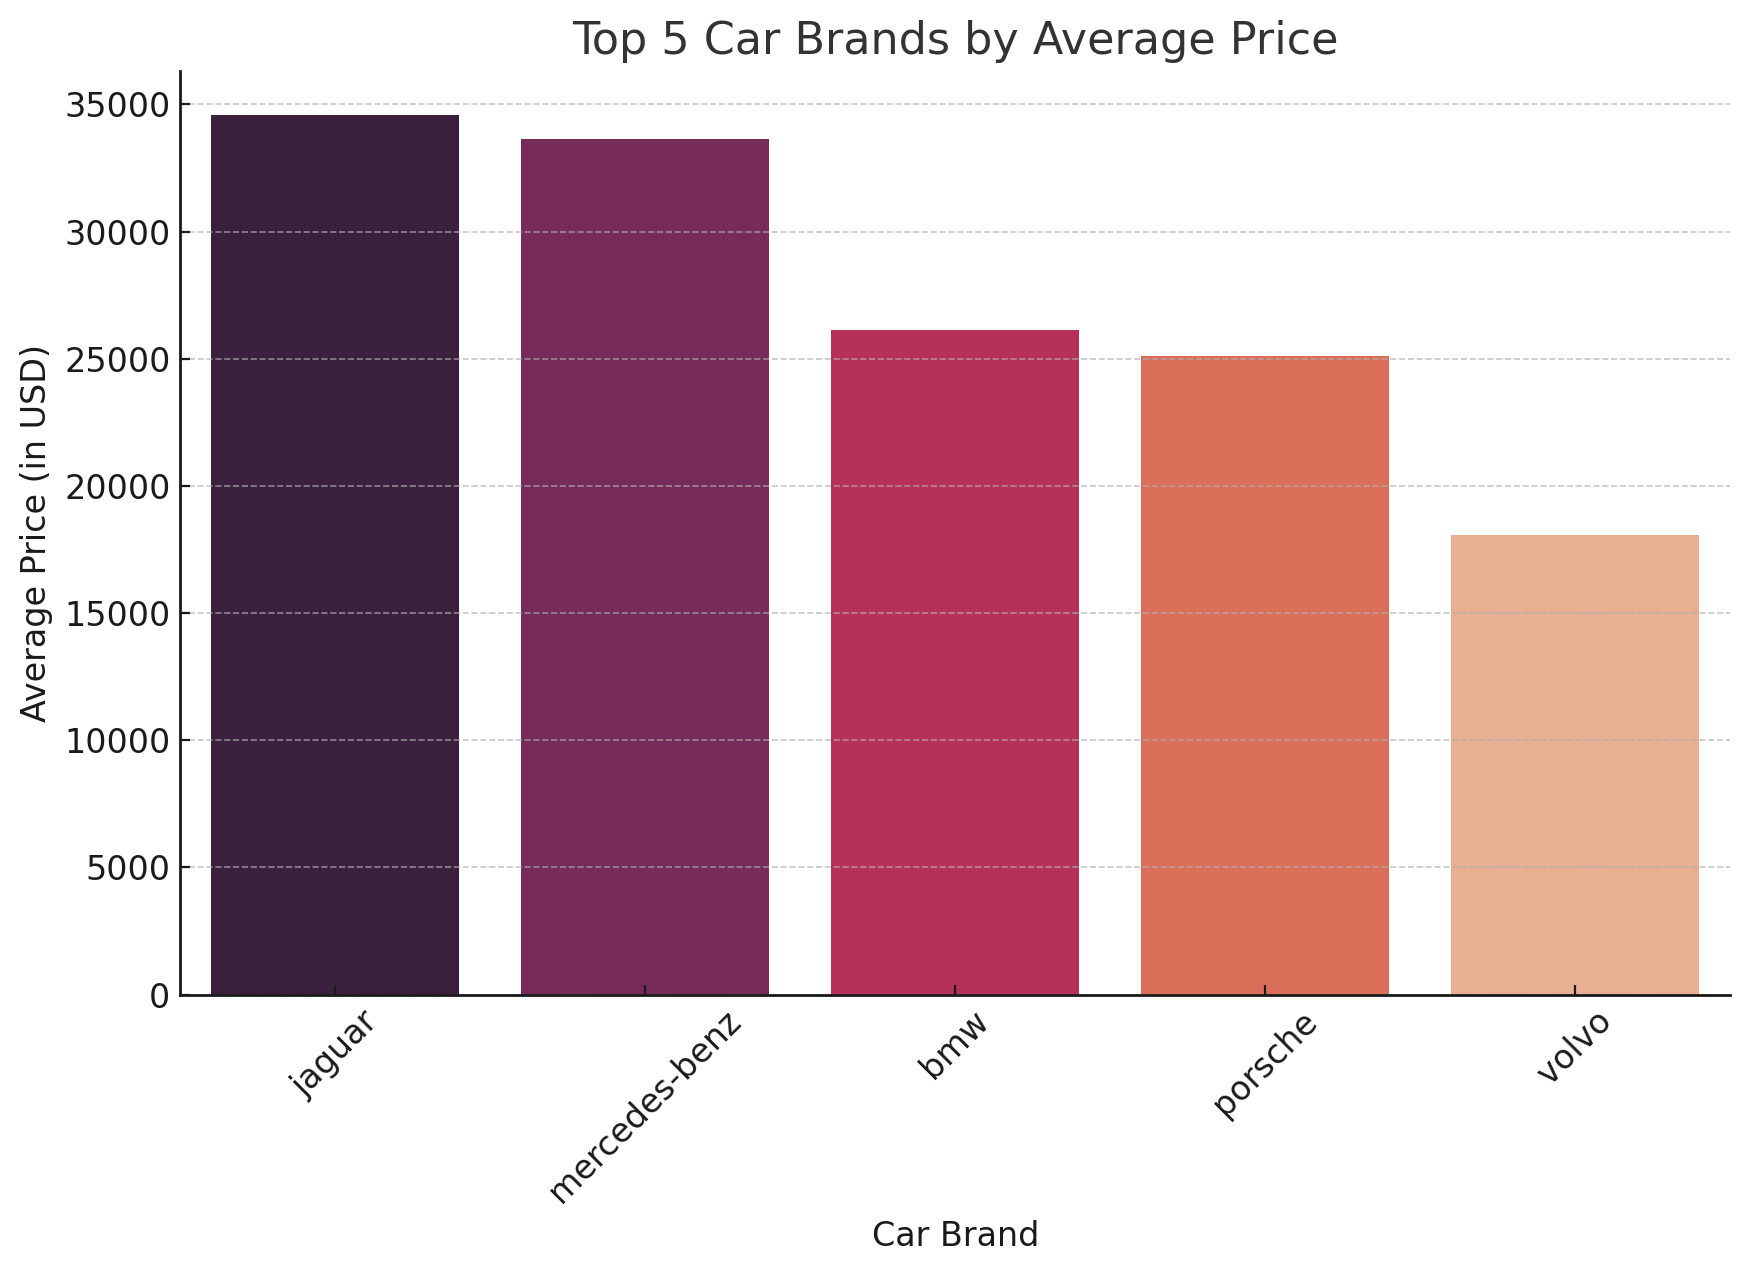

In [16]:
from IPython.display import Image, display
import io

run_steps = client.beta.threads.runs.steps.list(
    thread_id=thread.id,
    run_id=run.id,
    order="asc"
)

print(f"Total run steps: {len(run_steps.data)}")
print("=" * 60)

for step in run_steps.data:
    if step.type == "tool_calls":
        for tool_call in step.step_details.tool_calls:
            if tool_call.type == "code_interpreter":
                # Show the code OpenAI wrote and executed
                if tool_call.code_interpreter.input:
                    print("\n--- CODE WRITTEN BY OPENAI ---")
                    print(tool_call.code_interpreter.input)
                
                # Show outputs
                for output in tool_call.code_interpreter.outputs:
                    if output.type == "logs":
                        print("\n--- OUTPUT ---")
                        print(output.logs)
                    elif output.type == "image":
                        print("\n--- IMAGE GENERATED ---")
                        # Download and display the chart
                        image_data = client.files.content(output.image.file_id)
                        display(Image(data=image_data.read()))

---
## Step 7 — Retrieve the Final Assistant Message

After the run steps, we fetch the assistant's final text response from the thread.

This is `process_message_content()` in `main.py` (lines 689–760).

/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/3542694342.py:3: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  messages = client.beta.threads.messages.list(


Role: assistant


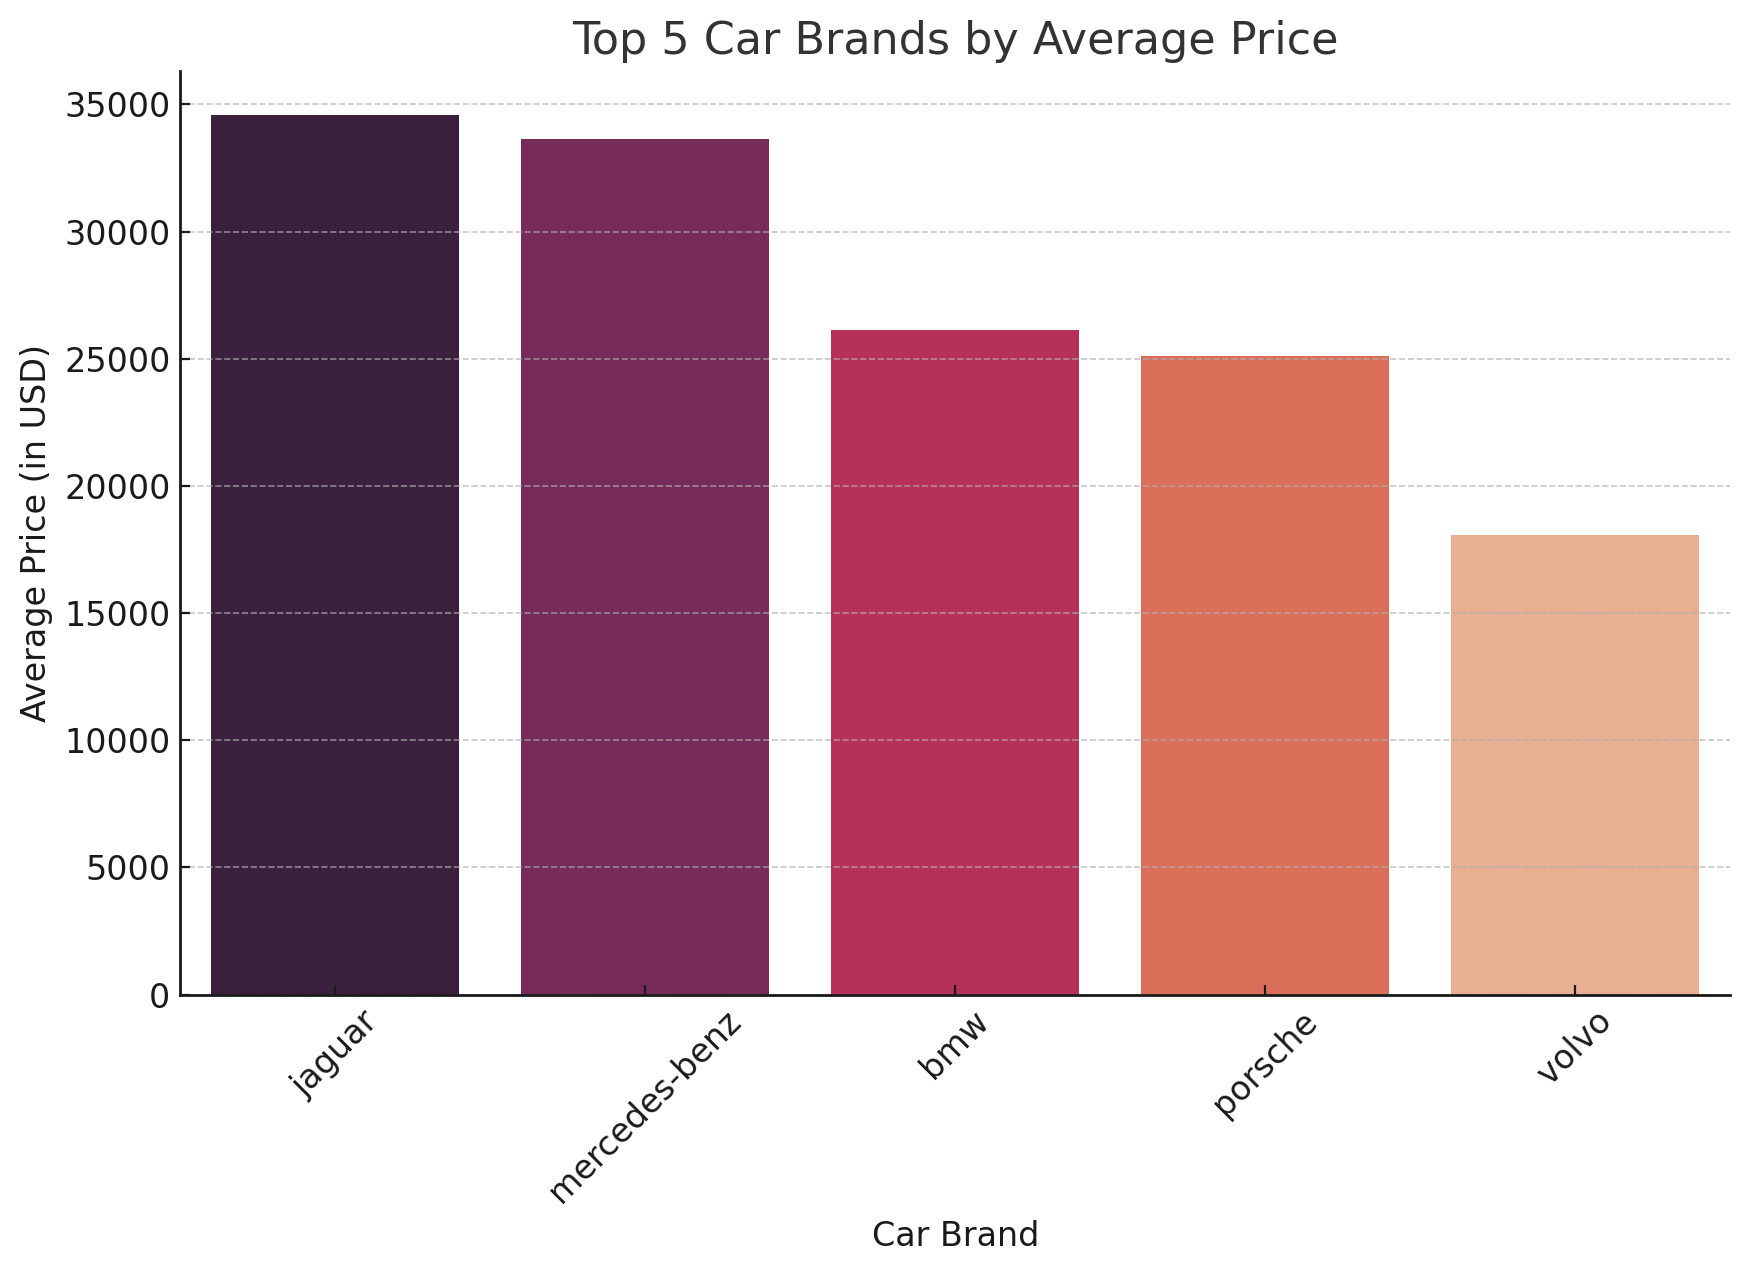

The top 5 car brands by average price are:

1. **Jaguar** with an average price of around \$35,000
2. **Mercedes-Benz** with an average price of nearly \$34,500
3. **BMW** averaging approximately \$32,500
4. **Porsche** with an average price around \$31,500
5. **Volvo** with an average price close to \$22,500

These brands are recognized for their luxury and performance vehicles, which often come with higher price points compared to other brands.

### Follow-up Questions:
1. How does the average horsepower compare among the top 5 car brands?
2. What are the common fuel types among the top 5 brands with the highest average prices?
3. How do the average city and highway MPG figures compare among these top brands?

In [17]:
from IPython.display import Markdown

messages = client.beta.threads.messages.list(
    thread_id=thread.id,
    order="desc",
    limit=1
)

assistant_message = messages.data[0]
print(f"Role: {assistant_message.role}")
print("=" * 60)

for block in assistant_message.content:
    if block.type == "text":
        display(Markdown(block.text.value))
    elif block.type == "image_file":
        image_data = client.files.content(block.image_file.file_id)
        display(Image(data=image_data.read()))

---
## Step 8 — Continue the Conversation (Multi-turn)

Because the thread persists, we can ask a follow-up question — the assistant remembers the prior context and the data file.

/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/3054828081.py:3: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  client.beta.threads.messages.create(
/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/3054828081.py:10: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run2 = client.beta.threads.runs.create(
/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/3054828081.py:17: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run2 = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run2.id)


Status: completed


/var/folders/vr/mpmvnq3921n9j9rgk4zmcltw0000gp/T/ipykernel_88629/3054828081.py:24: DeprecationWarning: The Assistants API is deprecated in favor of the Responses API
  run2_steps = client.beta.threads.runs.steps.list(thread_id=thread.id, run_id=run2.id, order="asc")


--- CODE ---
# Plotting the distribution of car prices using a histogram
plt.figure(figsize=(10, 6))
sns.histplot(data['price'].dropna(), bins=30, kde=True, color='dodgerblue')

plt.title('Distribution of Car Prices')
plt.xlabel('Price (in USD)')
plt.ylabel('Number of Cars')
plt.style.use('dark_background')

plt.show()


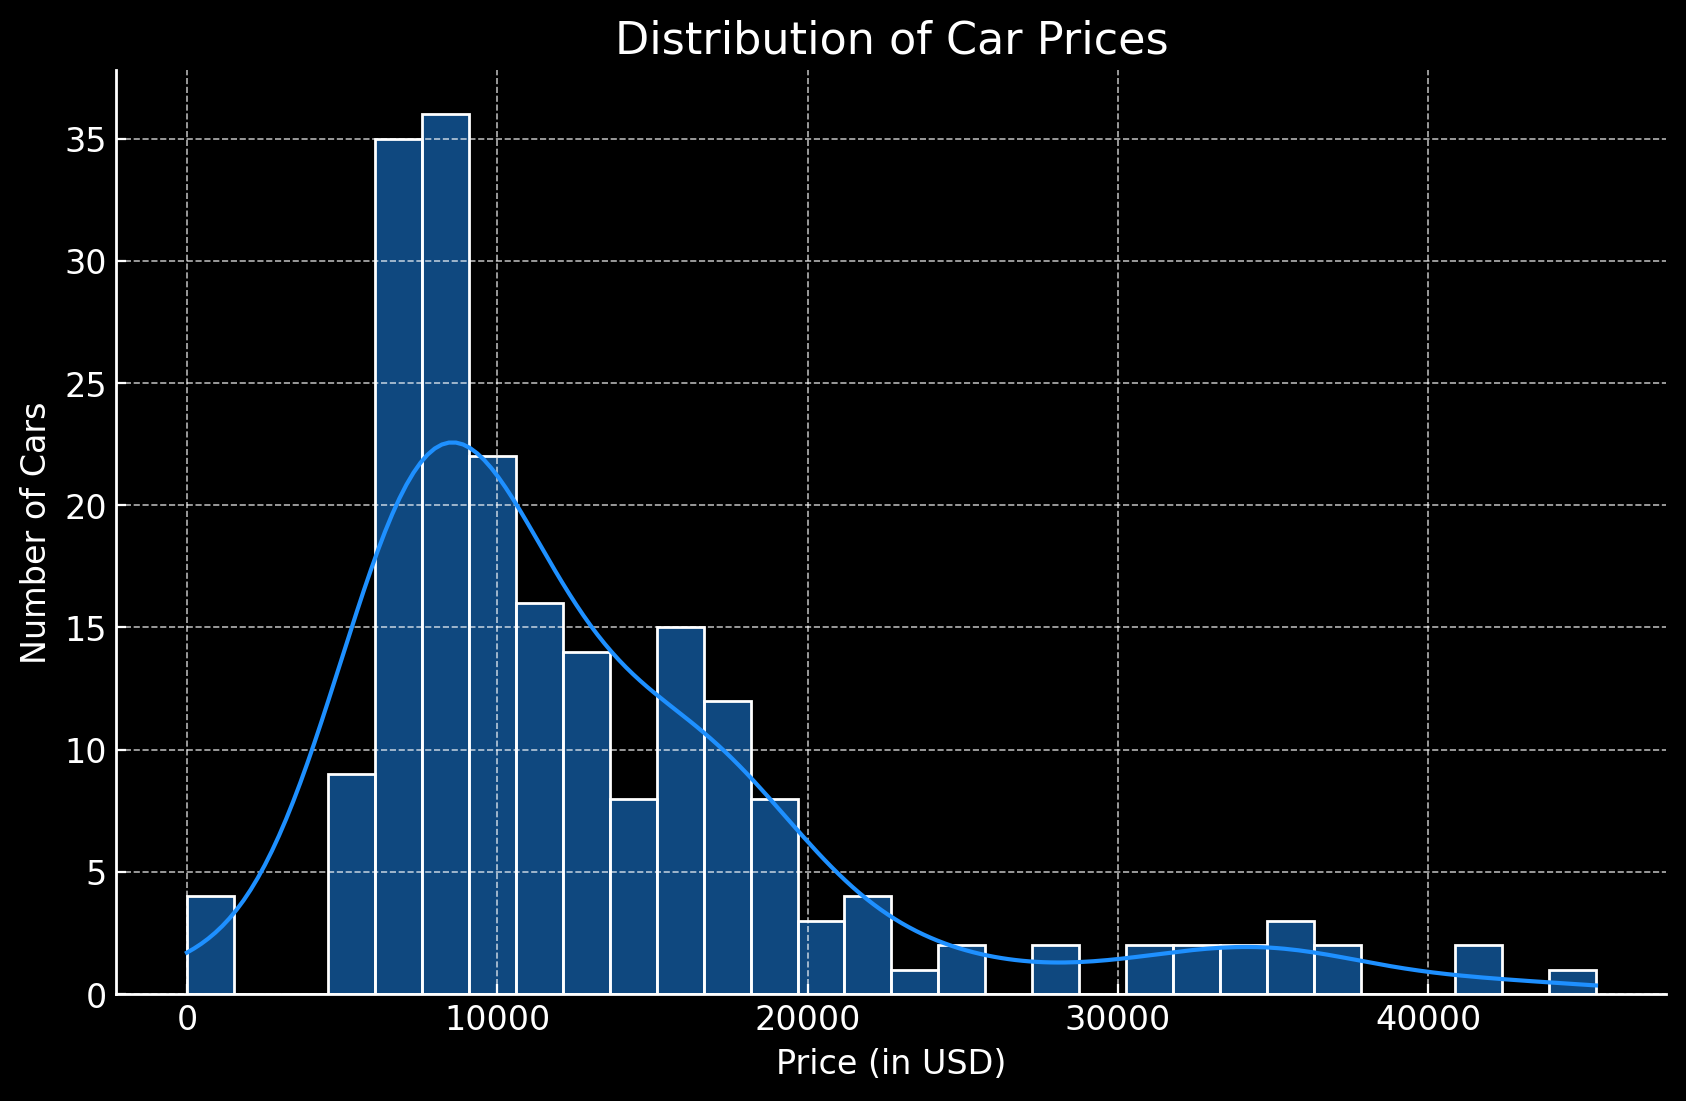

In [18]:
follow_up = "Now show the distribution of car prices as a histogram."

client.beta.threads.messages.create(
    thread_id=thread.id,
    role="user",
    content=follow_up
    # No need to re-attach the file — the thread already has it
)

run2 = client.beta.threads.runs.create(
    thread_id=thread.id,
    assistant_id=assistant.id
)

# Wait for completion
while True:
    run2 = client.beta.threads.runs.retrieve(thread_id=thread.id, run_id=run2.id)
    if run2.status in ["completed", "failed", "cancelled", "expired"]:
        print(f"Status: {run2.status}")
        break
    time.sleep(2)

# Show steps from the second run
run2_steps = client.beta.threads.runs.steps.list(thread_id=thread.id, run_id=run2.id, order="asc")
for step in run2_steps.data:
    if step.type == "tool_calls":
        for tc in step.step_details.tool_calls:
            if tc.type == "code_interpreter":
                if tc.code_interpreter.input:
                    print("--- CODE ---")
                    print(tc.code_interpreter.input)
                for out in tc.code_interpreter.outputs:
                    if out.type == "image":
                        img = client.files.content(out.image.file_id)
                        display(Image(data=img.read()))

---
## Step 9 — Cleanup

Always delete uploaded files when done to avoid unnecessary storage costs on OpenAI.

In `main.py` this is done in `cleanup_old_sessions()` (lines 575–603) and `/api/clear` (lines 1398–1431).

In [ ]:
# Delete the file from OpenAI
client.files.delete(openai_file.id)
print(f"Deleted file: {openai_file.id}")

# Note: the thread and assistant persist but the file is removed
# In production main.py also deletes the assistant when cleaning up old sessions

---
## Summary — What Full Mode Does

| Step | What happens | Key `main.py` location |
|------|-------------|------------------------|
| 1 | Create/reuse an OpenAI Assistant with Code Interpreter | `init_openai()` |
| 2 | Upload CSV to OpenAI file storage | `/api/upload` |
| 3 | Create a conversation Thread | `get_session()` |
| 4 | Add user message with file attachment | `chat_full_mode()` |
| 5 | Start a Run and poll for completion | `chat_full_mode()` |
| 6 | Retrieve Run Steps: code + stdout + images | `process_run_steps()` |
| 7 | Retrieve final assistant text message | `process_message_content()` |
| 8 | Continue multi-turn conversation | same thread, new Run |
| 9 | Delete files on session end | `cleanup_old_sessions()` |

### Pros and Cons of Full Mode

| Pros | Cons |
|------|------|
| Model sees real data — most accurate analysis | Data leaves your machine (privacy concern) |
| Fully autonomous: model writes, runs, debugs code | Requires OpenAI file storage (costs) |
| Multi-turn memory with full context | Slower (round trip to OpenAI sandbox) |
| Supports file exports (PPTX, Excel) from sandbox | Dependent on OpenAI uptime |

For a privacy-preserving alternative, see **`chat_privacy_mode.ipynb`**.

You can access a complete full-stack app here: https://datajarvis.ai (select app data analyst agent)